# 07 · Figuras y tablas del informe

Este notebook consolida **todas las visualizaciones mínimas** exigidas en la sección 6 del enunciado, a partir de los resultados ya calculados en los notebooks 01–06. **No resuelve ningún modelo ni regenera escenarios**: solo lee las salidas guardadas en `data/processed/` y `results/`.

| Figura | Enunciado (sección 6) |
|---|---|
| 1 | Mapa comparativo de $x^\star$ y $x^{prom}$, con depósito, sitios y orden de visita |
| 2a | Matriz / mapa de calor con los tamaños de los 110 pools |
| 2b | Distribuciones de al menos cuatro arcos |
| 3 | Evolución de $LB$, $UB$, brecha y número acumulado de cortes |
| 4 | Comparación de costos, frecuencias de recurso y tiempos de cómputo |
| 5 | Composición del costo fuera de muestra y tercerización promedio por sitio |
| 6 | *(extra)* Distribución del tiempo de viaje $T(x^\star,\xi^s)$ y umbrales de activación del recurso |

**Archivos generados:**
- `results/figures/*.png` → gráficas comparativas de los enfoques.  
- `results/tables/comparacion_enfoques.csv` → tabla con los resultados consolidados.

## 1. Carga de resultados

Todos los insumos ya están versionados en el repositorio; este notebook no recalcula nada.

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROC_DIR = Path("../data/processed")
RESULTS_TABLES = Path("../results/tables")
RESULTS_LOGS = Path("../results/logs")
FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.grid": True, "grid.alpha": 0.3,
})

sites = pd.read_csv(PROC_DIR / "sites.csv")
arc_costs = pd.read_csv(PROC_DIR / "arc_costs.csv")
arc_order = pd.read_csv(PROC_DIR / "arc_order.csv")
pools = pd.read_parquet(PROC_DIR / "pools.parquet")
scenarios_K200 = pd.read_parquet(PROC_DIR / "scenarios_K200.parquet")

with open(RESULTS_TABLES / "extensive_form_K50_solution.json") as f:
    res_ext = json.load(f)
with open(PROC_DIR / "lshaped_K50_solution.json") as f:
    res_ls50 = json.load(f)
with open(PROC_DIR / "main_experiment_K200_results.json") as f:
    res_main = json.load(f)
with open(RESULTS_TABLES / "out_of_sample_february_results.json") as f:
    res_oos = json.load(f)

conv_K50 = pd.read_csv(RESULTS_LOGS / "lshaped_convergence_K50.csv")
conv_K200 = pd.read_csv(RESULTS_LOGS / "lshaped_convergence_K200.csv")
cost_comp = pd.read_csv(PROC_DIR / "out_of_sample_cost_composition.csv")
outsourcing = pd.read_csv(PROC_DIR / "out_of_sample_outsourcing_by_site.csv")

V = sites["i"].tolist()
A = list(zip(arc_order["i"], arc_order["j"]))
coord = sites.set_index("i")[["lat", "lon"]].to_dict("index")

route_star = res_main["route_star"]
route_prom = res_main["route_prom"]
routes_identical = res_main["routes_identical"]

short_names = {0: "Javits (depósito)", 1: "Times Sq", 2: "Rockefeller", 3: "Grand Central",
               4: "NY Public Lib", 5: "Union Sq", 6: "Washington Sq", 7: "Madison SG",
               8: "One WTC", 9: "NYSE", 10: "Seaport"}

print(f"Ruta x*     : {route_star}")
print(f"Ruta x_prom : {route_prom}")
print(f"¿Idénticas? : {routes_identical}")

Ruta x*     : [0, 7, 1, 2, 3, 4, 5, 6, 10, 9, 8, 0]
Ruta x_prom : [0, 7, 1, 2, 3, 4, 5, 6, 10, 9, 8, 0]
¿Idénticas? : True


## 2. Figura 1 · Mapa comparativo de $x^\star$ y $x^{prom}$

Ambos paneles usan las coordenadas de `sites.csv`. El depósito se marca con una estrella y cada sitio lleva su número de orden de visita; el recuadro traduce esos números a nombres.Se indica explícitamente si las dos rutas coinciden, así que el subtítulo se genera automáticamente a partir de `routes_identical`.

Basemap descargado: Esri WorldGrayCanvas


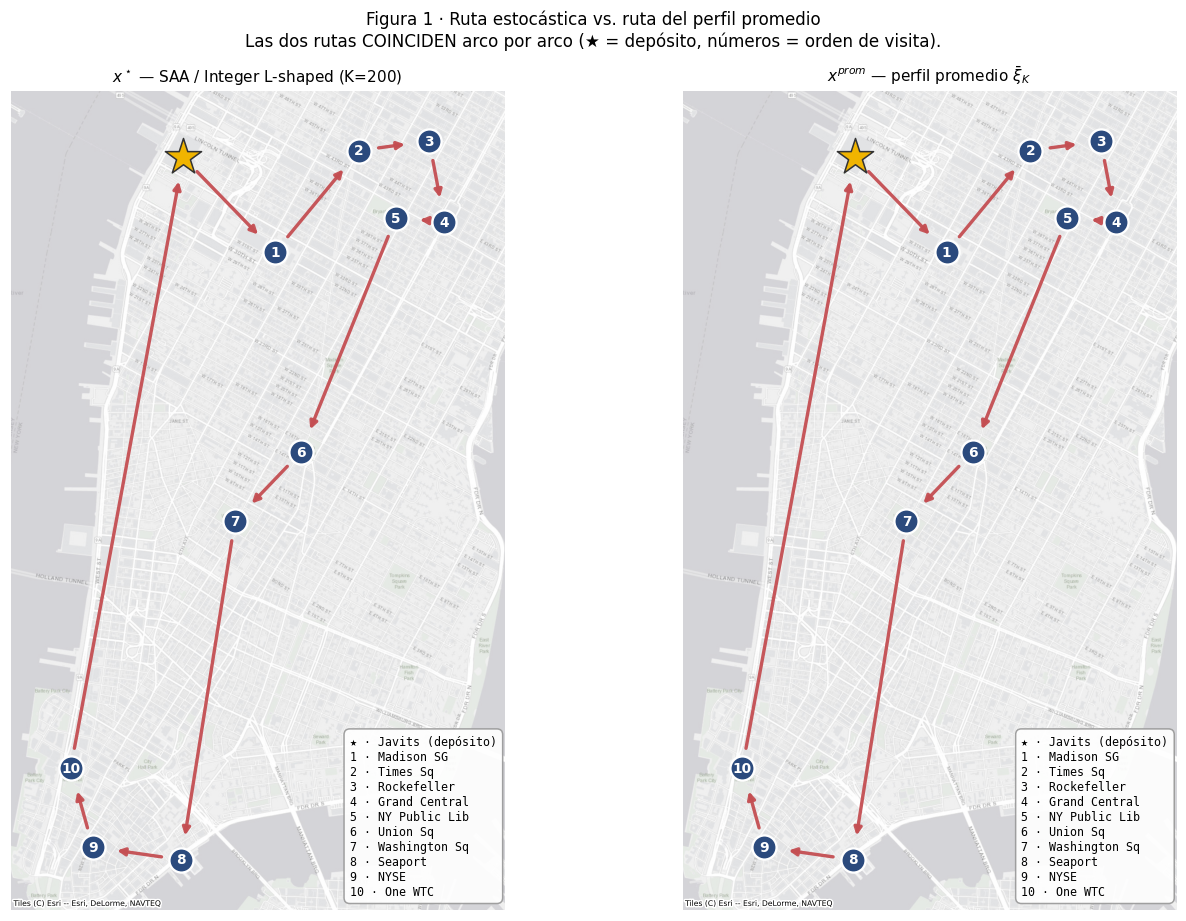

Orden de visita: Javits (depósito) → Madison SG → Times Sq → Rockefeller → Grand Central → NY Public Lib → Union Sq → Washington Sq → Seaport → NYSE → One WTC → Javits (depósito)


In [15]:

try:
    import contextily as cx
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "contextily"], check=False)
    try:
        import contextily as cx
    except ModuleNotFoundError:
        cx = None

R_EARTH = 6378137.0

def to_mercator(lat, lon):
    """Convierte (lat, lon) en grados a Web Mercator (EPSG:3857), en metros."""
    return R_EARTH * np.radians(lon), R_EARTH * np.log(np.tan(np.pi / 4 + np.radians(lat) / 2))

xy = {i: to_mercator(coord[i]["lat"], coord[i]["lon"]) for i in V}

all_x = [xy[i][0] for i in V]; all_y = [xy[i][1] for i in V]
mx = 0.16 * (max(all_x) - min(all_x)); my = 0.07 * (max(all_y) - min(all_y))
XLIM = (min(all_x) - mx, max(all_x) + mx)
YLIM = (min(all_y) - my, max(all_y) + my)


def draw_route(ax, route, title, con_basemap):
    """Dibuja una ruta sobre el mapa, con el orden de visita numerado."""
    for k in range(len(route) - 1):
        a, b = route[k], route[k + 1]
        ax.annotate("", xy=xy[b], xytext=xy[a], zorder=2,
                    arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#c44e52",
                                    alpha=0.95, shrinkA=13, shrinkB=16))
    ax.scatter([xy[i][0] for i in V[1:]], [xy[i][1] for i in V[1:]],
               s=250, c="#2b4a7d", zorder=3, edgecolors="white", linewidths=1.5)
    ax.scatter([xy[0][0]], [xy[0][1]], s=620, marker="*", c="#f0b400", zorder=4,
               edgecolors="#333333", linewidths=1.0)
    for pos, i in enumerate(route[:-1]):
        if i != 0:
            ax.annotate(f"{pos}", xy[i], color="white", fontsize=9, ha="center",
                        va="center", zorder=5, fontweight="bold")

    orden = "\n".join(["★ · " + short_names[0]] +
                      [f"{p} · {short_names[i]}" for p, i in enumerate(route[:-1]) if i != 0])
    ax.text(0.985, 0.015, orden, transform=ax.transAxes, fontsize=7.6, ha="right",
            va="bottom", family="monospace", multialignment="left", zorder=6,
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#999999", alpha=0.92))

    ax.set_title(title, fontsize=10)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal")
    if con_basemap:
        ax.set_axis_off()
    else:
        ax.tick_params(labelleft=True, labelbottom=True)
        ax.set_xlabel("x (Web Mercator, m)"); ax.set_ylabel("y (Web Mercator, m)")
        ax.ticklabel_format(style="plain", useOffset=False)


fig, axes = plt.subplots(1, 2, figsize=(13, 8.5))
for ax in axes:
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal")

basemap_ok = False
if cx is not None:
    proveedores = [
        ("Esri WorldGrayCanvas", cx.providers.Esri.WorldGrayCanvas),
        ("Esri WorldStreetMap",  cx.providers.Esri.WorldStreetMap),
        ("OpenStreetMap Mapnik", cx.providers.OpenStreetMap.Mapnik),
    ]
    for nombre, proveedor in proveedores:
        try:
            for ax in axes:
                cx.add_basemap(ax, source=proveedor, zoom=15, attribution_size=5, alpha=0.9)
            basemap_ok = True
            print(f"Basemap descargado: {nombre}")
            break
        except Exception as err:
            print(f"No se pudo usar {nombre} ({type(err).__name__}).")
if not basemap_ok:
    print("Se dibuja el mapa sin fondo cartográfico (sin red o contextily no disponible).")

draw_route(axes[0], route_star, r"$x^\star$ — SAA / Integer L-shaped (K=200)", basemap_ok)
draw_route(axes[1], route_prom, r"$x^{prom}$ — perfil promedio $\bar\xi_K$", basemap_ok)

nota = ("Las dos rutas COINCIDEN arco por arco (★ = depósito, números = orden de visita)."
        if routes_identical else
        "Las dos rutas DIFIEREN (★ = depósito, números = orden de visita).")
fig.suptitle("Figura 1 · Ruta estocástica vs. ruta del perfil promedio\n" + nota, fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_mapa_rutas.png")
plt.show()

print("Orden de visita:", " → ".join(short_names[i] for i in route_star))

## 3. Figura 2a · Mapa de calor con el tamaño de los 110 pools

Matriz $11\times 11$ con $|P_{ij}|$ (diagonal vacía porque $A$ excluye los lazos). La escala de color es logarítmica porque los tamaños abarcan dos órdenes de magnitud; el número exacto se anota en cada celda.

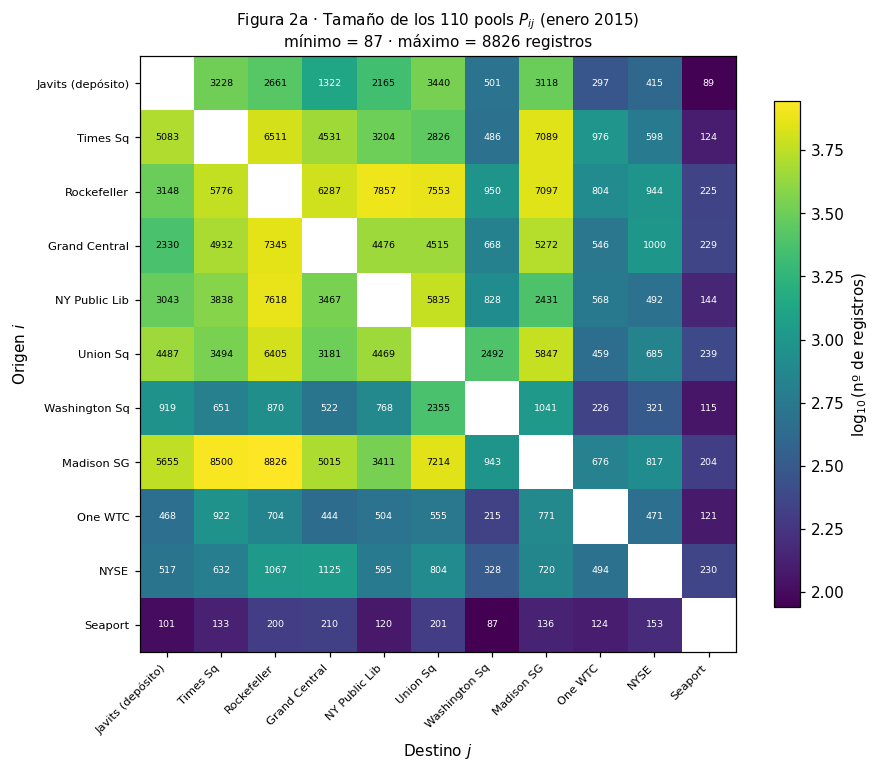

Pools: 110 | mínimo 87 registros (arco [10.0, 6.0]) | máximo 8826


In [5]:
M = np.full((len(V), len(V)), np.nan)
for r in arc_costs.itertuples():
    M[r.i, r.j] = r.n_trips

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(np.log10(M), cmap="viridis")

ax.set_xticks(range(len(V))); ax.set_yticks(range(len(V)))
ax.set_xticklabels([short_names[i] for i in V], rotation=45, ha="right", fontsize=7.5)
ax.set_yticklabels([short_names[i] for i in V], fontsize=7.5)

for i in range(len(V)):
    for j in range(len(V)):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{int(M[i, j])}", ha="center", va="center", fontsize=6.2,
                    color="white" if np.log10(M[i, j]) < 3.2 else "black")

cb = fig.colorbar(im, ax=ax, shrink=0.85)
cb.set_label(r"$\log_{10}$(nº de registros)")
ax.set_xlabel("Destino $j$"); ax.set_ylabel("Origen $i$"); ax.grid(False)
ax.set_title(f"Figura 2a · Tamaño de los {len(arc_costs)} pools $P_{{ij}}$ (enero 2015)\n"
             f"mínimo = {int(arc_costs.n_trips.min())} · máximo = {int(arc_costs.n_trips.max())} registros",
             fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2a_heatmap_pools.png")
plt.show()

print(f"Pools: {len(arc_costs)} | mínimo {int(arc_costs.n_trips.min())} registros "
      f"(arco {arc_costs.loc[arc_costs.n_trips.idxmin(), ['i', 'j']].tolist()}) | "
      f"máximo {int(arc_costs.n_trips.max())}")

## 4. Figura 2b · Distribuciones de cuatro arcos

Se eligen cuatro arcos **de la ruta óptima**, espaciados a lo largo del recorrido, y se superpone el pool completo de enero con la muestra SAA de $K=200$ para mostrar que el muestreo reproduce la distribución empírica. El eje $x$ se recorta en el percentil 99.5 para que las colas largas no aplasten la figura.

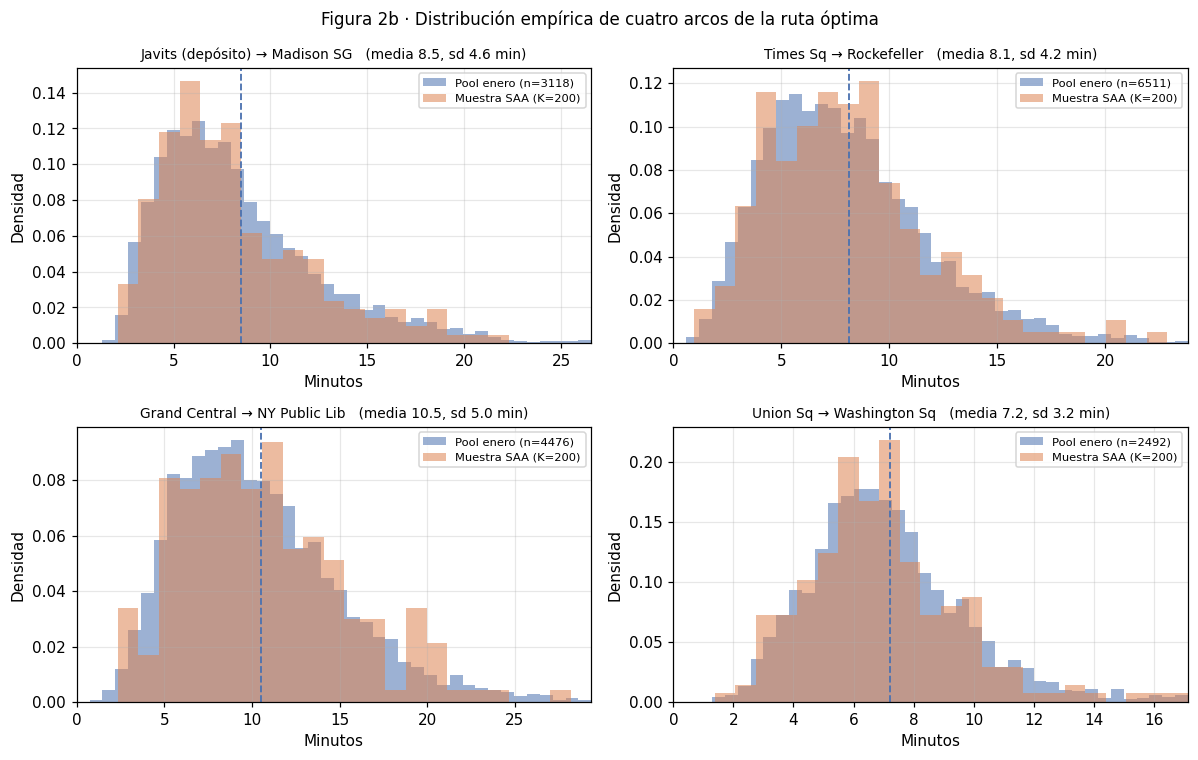

Arcos graficados: [(0, 7), (1, 2), (3, 4), (5, 6)]


In [6]:
arcs_ruta = [(route_star[k], route_star[k + 1]) for k in range(len(route_star) - 1)]
step = max(1, len(arcs_ruta) // 4)
arcos_fig = arcs_ruta[::step][:4]

pools_dict = {(i, j): g["t"].to_numpy() for (i, j), g in pools.groupby(["i", "j"])}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, a in zip(axes.flat, arcos_fig):
    v = pools_dict[a]
    m = scenarios_K200[f"xi_{a[0]}_{a[1]}"].to_numpy()
    lim = np.percentile(v, 99.5)
    ax.hist(v, bins=40, range=(0, lim), density=True, alpha=0.55, color="#4c72b0",
            label=f"Pool enero (n={len(v)})")
    ax.hist(m, bins=25, range=(0, lim), density=True, alpha=0.55, color="#dd8452",
            label="Muestra SAA (K=200)")
    ax.axvline(v.mean(), color="#4c72b0", ls="--", lw=1.2)
    ax.set_xlim(0, lim)
    ax.set_title(f"{short_names[a[0]]} → {short_names[a[1]]}   "
                 f"(media {v.mean():.1f}, sd {v.std():.1f} min)", fontsize=9)
    ax.set_xlabel("Minutos"); ax.set_ylabel("Densidad"); ax.legend(fontsize=7.5)

fig.suptitle("Figura 2b · Distribución empírica de cuatro arcos de la ruta óptima", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2b_distribuciones_arcos.png")
plt.show()

print("Arcos graficados:", arcos_fig)

## 5. Figura 3 · Convergencia del Integer L-shaped

Tres paneles por corrida: cotas $LB$/$UB$, brecha relativa en escala logarítmica contra la tolerancia $10^{-3}$, y número acumulado de cortes (estándar + enteros).

En el log, las iteraciones anteriores al primer incumbente tienen $UB=\infty$; se convierten a `NaN` para que matplotlib simplemente no las dibuje, y se marca con una línea vertical la iteración en que aparece la primera solución entera factible.

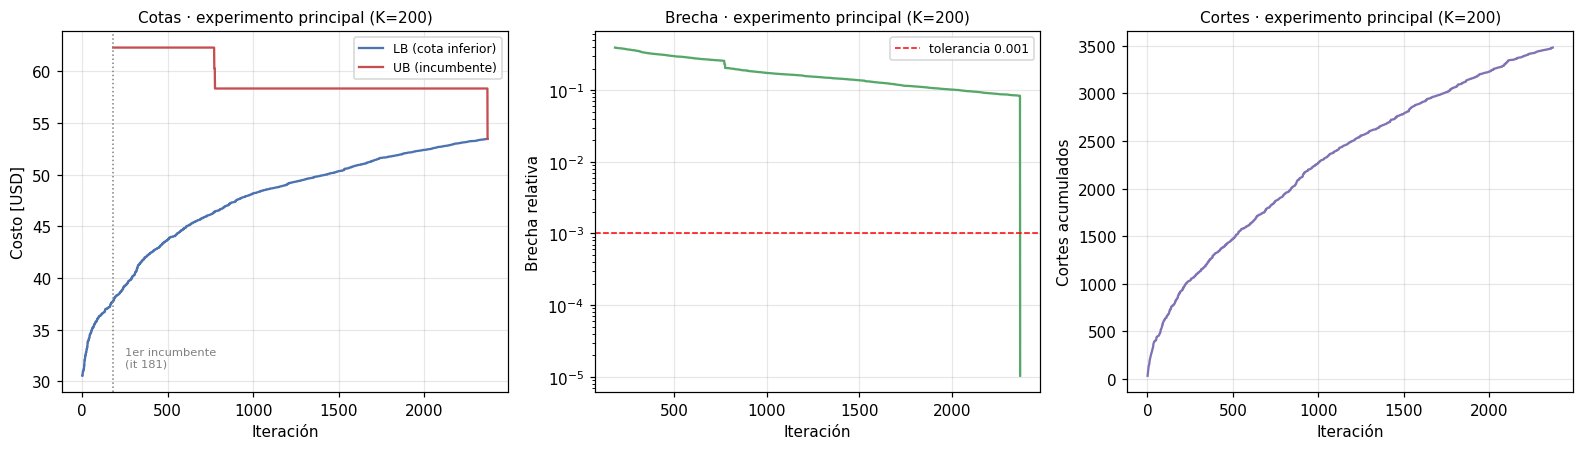

experimento principal (K=200): LB=53.4636 · UB=53.4642 · brecha=1.03e-05 · cortes=3483 · primer incumbente en it 181 de 2370


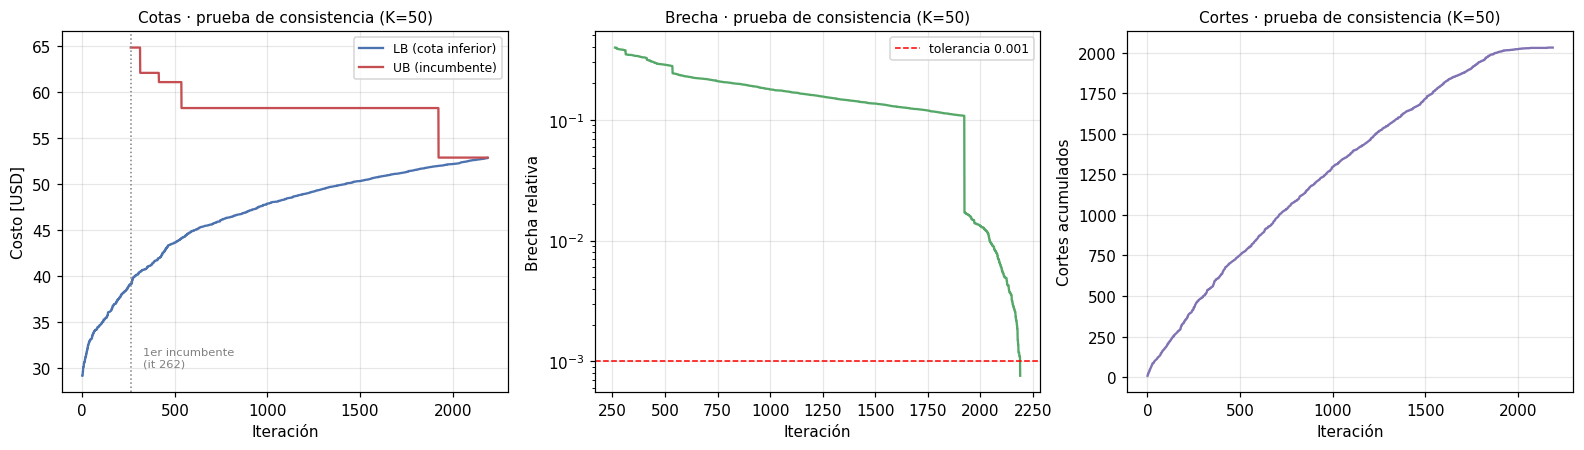

prueba de consistencia (K=50): LB=52.8443 · UB=52.8845 · brecha=7.60e-04 · cortes=2032 · primer incumbente en it 262 de 2189


In [7]:
def figura_convergencia(conv, etiqueta, fname, gap_tol=1e-3):
    c = conv.copy()
    c["UB"] = pd.to_numeric(c["UB"], errors="coerce").replace([np.inf, -np.inf], np.nan)
    c["gap"] = pd.to_numeric(c["gap"], errors="coerce").replace([np.inf, -np.inf], np.nan)
    it_ub = c.loc[c["UB"].notna(), "iteration"].min()

    fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))

    ax[0].plot(c.iteration, c.LB, lw=1.5, color="#4c72b0", label="LB (cota inferior)")
    ax[0].plot(c.iteration, c.UB, lw=1.5, color="#c44e52", label="UB (incumbente)")
    ax[0].axvline(it_ub, color="gray", ls=":", lw=1)
    ax[0].annotate(f"1er incumbente\n(it {int(it_ub)})", (it_ub, c.LB.iloc[0]),
                   textcoords="offset points", xytext=(8, 6), fontsize=7.5, color="gray")
    ax[0].set_xlabel("Iteración"); ax[0].set_ylabel("Costo [USD]")
    ax[0].set_title(f"Cotas · {etiqueta}", fontsize=10); ax[0].legend(fontsize=8)

    ax[1].plot(c.iteration, c.gap, lw=1.5, color="#55a868")
    ax[1].axhline(gap_tol, color="red", ls="--", lw=1, label=f"tolerancia {gap_tol:g}")
    ax[1].set_yscale("log"); ax[1].set_xlabel("Iteración"); ax[1].set_ylabel("Brecha relativa")
    ax[1].set_title(f"Brecha · {etiqueta}", fontsize=10); ax[1].legend(fontsize=8)

    ax[2].plot(c.iteration, c.n_cuts, lw=1.5, color="#8172b3")
    ax[2].set_xlabel("Iteración"); ax[2].set_ylabel("Cortes acumulados")
    ax[2].set_title(f"Cortes · {etiqueta}", fontsize=10)

    plt.tight_layout()
    plt.savefig(FIG_DIR / fname)
    plt.show()

    print(f"{etiqueta}: LB={c.LB.iloc[-1]:.4f} · UB={c.UB.iloc[-1]:.4f} · "
          f"brecha={c.gap.iloc[-1]:.2e} · cortes={int(c.n_cuts.iloc[-1])} · "
          f"primer incumbente en it {int(it_ub)} de {int(c.iteration.iloc[-1])}")


figura_convergencia(conv_K200, "experimento principal (K=200)", "fig3_convergencia_K200.png")
figura_convergencia(conv_K50, "prueba de consistencia (K=50)", "fig3b_convergencia_K50.png")

## 6. Figura 4 y tabla · Comparación de los tres enfoques

La tabla reúne valor objetivo, tamaño del modelo, tiempo de solución y brecha final de los cuatro modelos resueltos.

**Nota sobre el tamaño del modelo del L-shaped:** a diferencia de la forma extensa (un único MILP), el L-shaped resuelve un LP maestro *por nodo*, con $110$ variables $x$ + $10$ variables de orden MTZ + $\theta$ = **121 variables**, y $22$ restricciones de grado + $90$ restricciones MTZ + los cortes acumulados. Por eso el número de restricciones se reporta al final de la corrida, cuando todos los cortes ya se acumularon.

Los valores objetivo de la fila del perfil promedio **no son comparables** con los demás: evalúan $Q(x,\bar\xi_K)$ en un único bloque de recurso, no $Q_K(x)=\frac{1}{K}\sum_s Q(x,\xi^s)$.

In [8]:
n_cuts_K50 = res_ls50["n_std_cuts"] + res_ls50["n_int_cuts"]
n_cuts_K200 = res_main["lshaped"]["n_std_cuts"] + res_main["lshaped"]["n_int_cuts"]

N_X, N_U, N_THETA = len(A), len(V) - 1, 1
N_GRADO, N_MTZ = 2 * len(V), (len(V) - 1) * (len(V) - 2)
vars_master = N_X + N_U + N_THETA

tabla = pd.DataFrame([
    {"Enfoque": "Forma extensa (MILP, K=50)",
     "Valor objetivo": res_ext["objective"],
     "Variables": res_ext["n_variables"], "Restricciones": res_ext["n_constraints"],
     "Tiempo [s]": res_ext["solve_time_sec"], "Brecha final": 0.0,
     "Ruta": " → ".join(map(str, res_ext["route"]))},
    {"Enfoque": "Integer L-shaped (K=50)",
     "Valor objetivo": res_ls50["objective"],
     "Variables": vars_master, "Restricciones": N_GRADO + N_MTZ + n_cuts_K50,
     "Tiempo [s]": res_ls50["solve_time_sec"], "Brecha final": res_ls50["gap_final"],
     "Ruta": " → ".join(map(str, res_ls50["route"]))},
    {"Enfoque": "Integer L-shaped (K=200)",
     "Valor objetivo": res_main["lshaped"]["UB"],
     "Variables": vars_master, "Restricciones": N_GRADO + N_MTZ + n_cuts_K200,
     "Tiempo [s]": res_main["lshaped"]["solve_time_sec"], "Brecha final": res_main["lshaped"]["gap"],
     "Ruta": " → ".join(map(str, res_main["route_star"]))},
    {"Enfoque": "Perfil promedio (MILP, K=1)",
     "Valor objetivo": res_main["average_profile"]["objective_at_xi_bar"],
     "Variables": res_main["average_profile"]["n_variables"],
     "Restricciones": res_main["average_profile"]["n_constraints"],
     "Tiempo [s]": res_main["average_profile"]["solve_time_sec"], "Brecha final": 0.0,
     "Ruta": " → ".join(map(str, res_main["route_prom"]))},
])

tabla.to_csv(RESULTS_TABLES / "comparacion_enfoques.csv", index=False)
print(f"Guardado: {RESULTS_TABLES / 'comparacion_enfoques.csv'}\n")
tabla

Guardado: ../results/tables/comparacion_enfoques.csv



,Enfoque,Valor objetivo,Variables,Restricciones,Tiempo [s],Brecha final,Ruta
0,"Forma extensa (MILP, K=50)",52.884477,1220,1162,0.543843,0.00000,0 → 7 → 1 → 2 → 3 → 4 → 5 → 6 → 10 → 9 → 8 → 0
1,Integer L-shaped (K=50),52.884477,121,2144,179.702425,0.00076,0 → 7 → 1 → 2 → 3 → 4 → 5 → 6 → 10 → 9 → 8 → 0
2,Integer L-shaped (K=200),53.464168,121,3595,639.517861,0.00001,0 → 7 → 1 → 2 → 3 → 4 → 5 → 6 → 10 → 9 → 8 → 0
3,"Perfil promedio (MILP, K=1)",51.928594,142,133,0.201505,0.00000,0 → 7 → 1 → 2 → 3 → 4 → 5 → 6 → 10 → 9 → 8 → 0


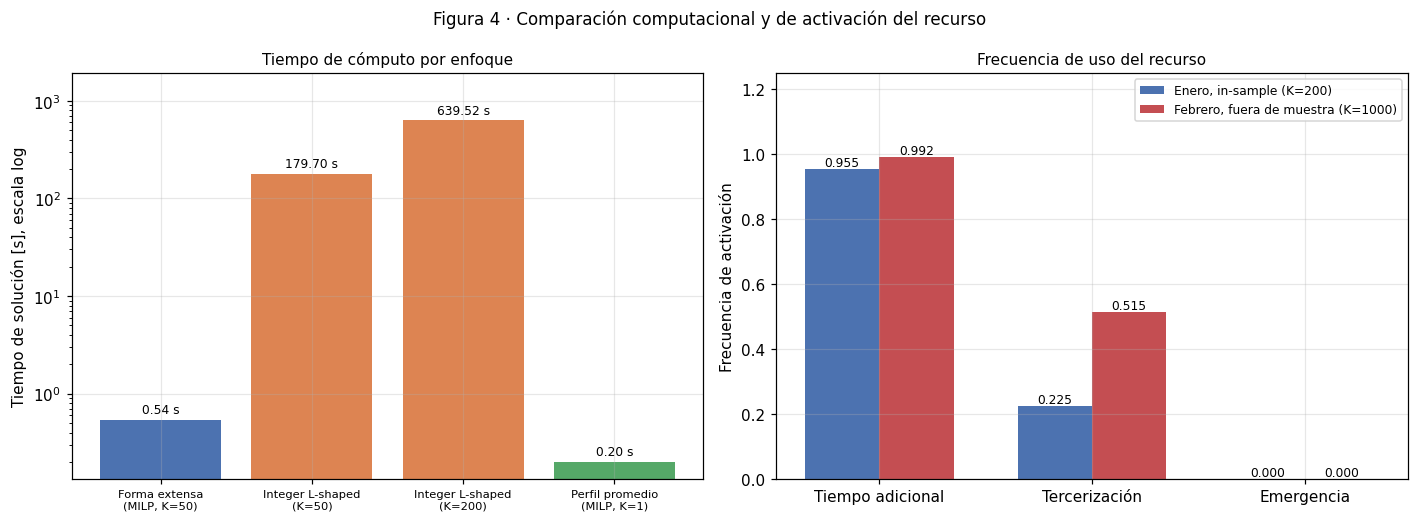

VSS_K = 0.000000   |   Delta_Feb = 0.000000   |   IC 95% pareado = [0.000000, 0.000000]


In [9]:
fr_in = res_main["resource_usage_frequencies"]
fr_out = res_oos["resource_usage_frequencies_out_of_sample"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

etq = [t.replace(" (", "\n(") for t in tabla["Enfoque"]]
colores_barras = ["#4c72b0", "#dd8452", "#dd8452", "#55a868"]
b = ax[0].bar(etq, tabla["Tiempo [s]"], color=colores_barras)
ax[0].set_yscale("log")
ax[0].set_ylabel("Tiempo de solución [s], escala log")
ax[0].tick_params(axis="x", labelsize=7.5)
ax[0].bar_label(b, fmt="%.2f s", fontsize=8, padding=2)
ax[0].set_ylim(top=tabla["Tiempo [s]"].max() * 3)
ax[0].set_title("Tiempo de cómputo por enfoque", fontsize=10)

cats = ["Tiempo adicional", "Tercerización", "Emergencia"]
xpos = np.arange(len(cats)); w = 0.35
v_in = [fr_in["x_star"]["overtime"], fr_in["x_star"]["outsourcing"], fr_in["x_star"]["emergency"]]
v_out = [fr_out["x_star"]["overtime"], fr_out["x_star"]["outsourcing"], fr_out["x_star"]["emergency"]]
b1 = ax[1].bar(xpos - w / 2, v_in, w, color="#4c72b0",
               label=f"Enero, in-sample (K={res_main['K']})")
b2 = ax[1].bar(xpos + w / 2, v_out, w, color="#c44e52",
               label=f"Febrero, fuera de muestra (K={res_oos['K_test']})")
ax[1].bar_label(b1, fmt="%.3f", fontsize=8); ax[1].bar_label(b2, fmt="%.3f", fontsize=8)
ax[1].set_xticks(xpos); ax[1].set_xticklabels(cats)
ax[1].set_ylim(0, 1.25); ax[1].set_ylabel("Frecuencia de activación")
ax[1].legend(fontsize=8, loc="upper right")
ax[1].set_title("Frecuencia de uso del recurso", fontsize=10)

fig.suptitle("Figura 4 · Comparación computacional y de activación del recurso", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_comparacion_enfoques.png")
plt.show()

print(f"VSS_K = {res_main['in_sample_comparison']['VSS_K']:.6f}   |   "
      f"Delta_Feb = {res_oos['Delta_Feb']:.6f}   |   "
      f"IC 95% pareado = [{res_oos['paired_diff']['ci_95_lower']:.6f}, "
      f"{res_oos['paired_diff']['ci_95_upper']:.6f}]")

## 7. Figura 5 · Composición del costo fuera de muestra y tercerización por sitio

Usa los dos CSV que produce la celda 6c del notebook 06. El panel izquierdo descompone $\widehat{C}_{Feb}(x)$ en primera etapa, tiempo adicional, tercerización y emergencia; el derecho muestra los minutos tercerizados promedio por sitio, con los sitios ordenados por costo unitario $c_i^{out}$ para hacer visible que el recurso terceriza en orden de precio.

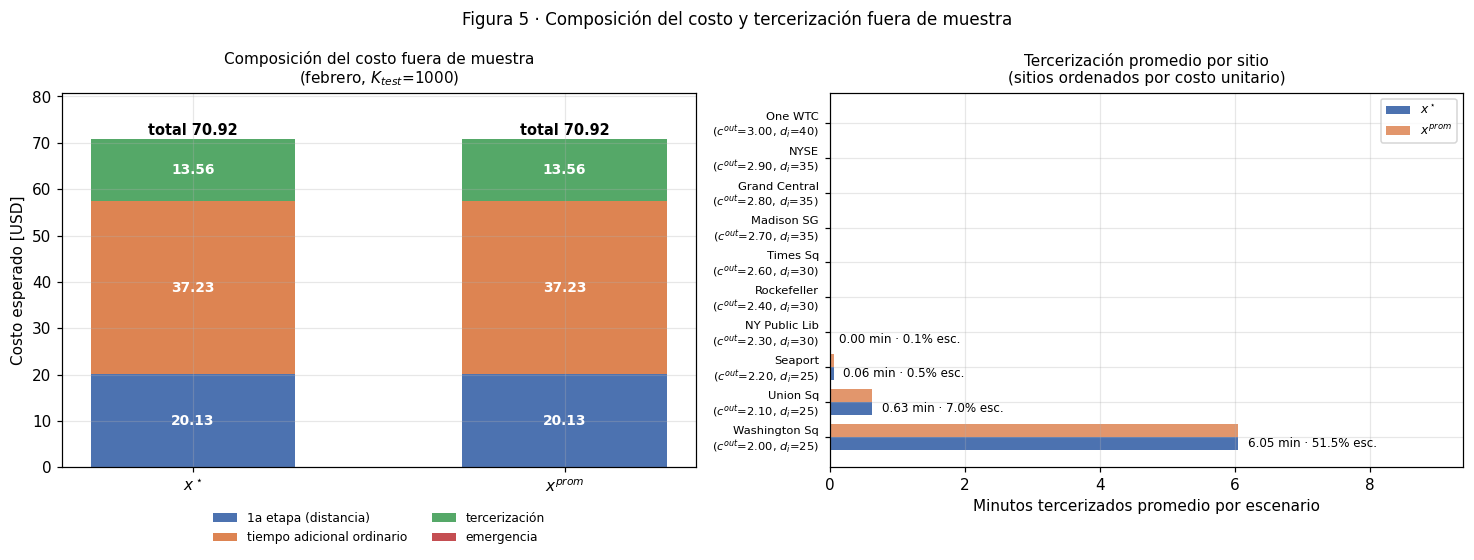

Sitios con tercerización activa fuera de muestra:
  sitio  6 (Washington Sq, c_out=2.00): 6.050 min promedio en 51.5% de los escenarios
  sitio  5 (Union Sq, c_out=2.10): 0.632 min promedio en 7.0% de los escenarios
  sitio 10 (Seaport, c_out=2.20): 0.058 min promedio en 0.5% de los escenarios
  sitio  4 (NY Public Lib, c_out=2.30): 0.002 min promedio en 0.1% de los escenarios


In [10]:
comp = cost_comp[cost_comp["componente"] != "TOTAL"].reset_index(drop=True)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.2))

rutas = ["$x^\\star$", "$x^{prom}$"]
cols = ["x_star", "x_prom"]
colores = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

bot = np.zeros(len(cols))
for k, row in comp.iterrows():
    vals = np.array([row[c] for c in cols])
    ax[0].bar(rutas, vals, bottom=bot, label=row["componente"], color=colores[k], width=0.55)
    for pos, (v, b0) in enumerate(zip(vals, bot)):
        if v > 0.5:
            ax[0].text(pos, b0 + v / 2, f"{v:.2f}", ha="center", va="center",
                       fontsize=9, color="white", fontweight="bold")
    bot += vals
for pos, tot in enumerate(bot):
    ax[0].text(pos, tot + 0.9, f"total {tot:.2f}", ha="center", fontsize=9.5, fontweight="bold")

ax[0].set_ylabel("Costo esperado [USD]"); ax[0].set_ylim(0, bot.max() * 1.14)
ax[0].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=2, frameon=False)
ax[0].set_title(f"Composición del costo fuera de muestra\n"
                f"(febrero, $K_{{test}}$={res_oos['K_test']})", fontsize=10)

o = outsourcing.sort_values("c_out_i")
y = np.arange(len(o)); w = 0.38
ax[1].barh(y - w / 2, o["r_prom_star_min"], w, color="#4c72b0", label="$x^\\star$")
ax[1].barh(y + w / 2, o["r_prom_prom_min"], w, color="#dd8452", label="$x^{prom}$", alpha=0.85)
ax[1].set_yticks(y)
ax[1].set_yticklabels([f"{short_names[int(s)]}\n($c^{{out}}$={c:.2f}, $d_i$={int(d)})"
                       for s, c, d in zip(o["sitio"], o["c_out_i"], o["d_i"])], fontsize=7.5)
ax[1].set_xlim(0, max(o["r_prom_star_min"].max(), o["r_prom_prom_min"].max()) * 1.55)
for k, (v, p) in enumerate(zip(o["r_prom_star_min"], o["P(r_i>0)_star"])):
    if v > 1e-4:
        ax[1].text(v + ax[1].get_xlim()[1] * 0.015, k - w / 2,
                   f"{v:.2f} min · {p:.1%} esc.", va="center", fontsize=7.8)
ax[1].set_xlabel("Minutos tercerizados promedio por escenario")
ax[1].legend(fontsize=8, loc="upper right")
ax[1].set_title("Tercerización promedio por sitio\n(sitios ordenados por costo unitario)", fontsize=10)

fig.suptitle("Figura 5 · Composición del costo y tercerización fuera de muestra", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_composicion_costo_oos.png")
plt.show()

activos = o[o["r_prom_star_min"] > 1e-4]
print("Sitios con tercerización activa fuera de muestra:")
for _, row in activos.iterrows():
    s_i = int(row["sitio"])
    print(f"  sitio {s_i:2d} ({short_names[s_i]}, c_out={row['c_out_i']:.2f}): "
          f"{row['r_prom_star_min']:.3f} min promedio en "
          f"{row['P(r_i>0)_star']:.1%} de los escenarios")

## 8. Figura 6 *(extra)* · Distribución del tiempo de viaje y umbrales de activación

Figura adicional, útil para la discusión: como $\alpha_i=1$ y $\sum_i d_i = 310$, el recurso depende de $x$ únicamente a través del tiempo total de viaje $T(x,\xi^s)=\sum_{(i,j)}\xi^{(s)}_{ij}x_{ij}$. Los umbrales son:

- $T > H-\sum_i d_i = 80$ min → se activa el tiempo adicional ordinario;
- $T > 80+\bar o = 110$ min → se agota el tiempo adicional y empieza la tercerización;
- $T > 80+\bar o+\sum_i d_i = 420$ min → se necesitaría sobretiempo de emergencia.

Esto explica las frecuencias de la Figura 4 y por qué $e^{(s)}=0$ en todos los escenarios.

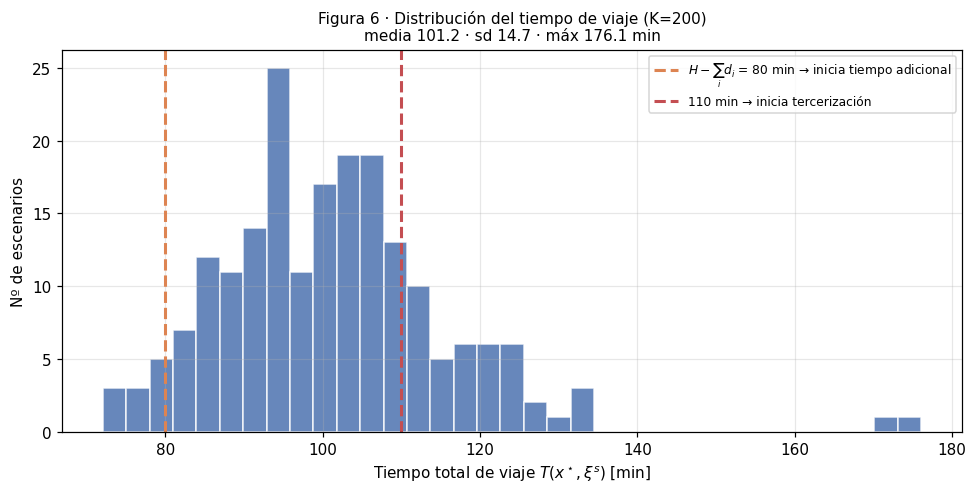

P(T > 80) = 95.5%  → coincide con la frecuencia de tiempo adicional
P(T > 110) = 22.5%  → coincide con la frecuencia de tercerización
Umbral de emergencia = 420 min; máximo observado = 176.1 min → la emergencia es inalcanzable en esta instancia.


In [11]:
H, o_bar = 390.0, 30.0
d_i = {1: 30, 2: 30, 3: 35, 4: 30, 5: 25, 6: 25, 7: 35, 8: 40, 9: 35, 10: 25}
D_total = sum(d_i.values())

idx = {a: k for k, a in enumerate(A)}
XI = scenarios_K200[[f"xi_{i}_{j}" for i, j in A]].to_numpy()
T = XI[:, [idx[a] for a in arcs_ruta]].sum(axis=1)

u1 = H - D_total            # 80  min  -> inicia sobretiempo ordinario
u2 = u1 + o_bar             # 110 min  -> inicia tercerización
u3 = u2 + D_total           # 420 min  -> inicia emergencia

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(T, bins=35, color="#4c72b0", alpha=0.85, edgecolor="white")
ax.axvline(u1, color="#dd8452", ls="--", lw=2,
           label=f"$H-\\sum_i d_i$ = {u1:.0f} min → inicia tiempo adicional")
ax.axvline(u2, color="#c44e52", ls="--", lw=2,
           label=f"{u2:.0f} min → inicia tercerización")
ax.set_xlabel(r"Tiempo total de viaje $T(x^\star,\xi^s)$ [min]")
ax.set_ylabel("Nº de escenarios")
ax.set_title(f"Figura 6 · Distribución del tiempo de viaje (K={len(T)})\n"
             f"media {T.mean():.1f} · sd {T.std():.1f} · máx {T.max():.1f} min", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_distribucion_T.png")
plt.show()

print(f"P(T > {u1:.0f}) = {100 * (T > u1).mean():.1f}%  → coincide con la frecuencia de tiempo adicional")
print(f"P(T > {u2:.0f}) = {100 * (T > u2).mean():.1f}%  → coincide con la frecuencia de tercerización")
print(f"Umbral de emergencia = {u3:.0f} min; máximo observado = {T.max():.1f} min "
      f"→ la emergencia es inalcanzable en esta instancia.")

## 9. Resumen de archivos generados

In [12]:
generados = sorted(FIG_DIR.glob("*.png"))
print(f"Figuras en {FIG_DIR}:")
for p in generados:
    print(f"  {p.name:38s} {p.stat().st_size / 1024:7.1f} KB")
print(f"\nTabla: {RESULTS_TABLES / 'comparacion_enfoques.csv'}")

Figuras en ../results/figures:
  fig1_mapa_rutas.png                      173.1 KB
  fig2a_heatmap_pools.png                  224.9 KB
  fig2b_distribuciones_arcos.png           168.6 KB
  fig3_convergencia_K200.png               149.7 KB
  fig3b_convergencia_K50.png               156.8 KB
  fig4_comparacion_enfoques.png            127.5 KB
  fig5_composicion_costo_oos.png           197.5 KB
  fig6_distribucion_T.png                   70.1 KB

Tabla: ../results/tables/comparacion_enfoques.csv
